In [1]:
import pandas as pd
import numpy as np
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import RandomForestRegressor
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', 20)
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
from scipy.stats import randint, uniform
import joblib
import csv

### Data Preprocessing

In [2]:
df = pd.read_csv("./datasets/new_raw.csv")
first = ["name", "nvar"]
df = df[first + [c for c in df.columns if c not in first]]
df["nvar"].value_counts
df = df.sort_values(["name", "nvar", "mem"]).reset_index()
df

,index,name,nvar,nvmops,objective,eval_duration_solver,extract_duration_solver,stats_elapsed_time,dual_feas,status,timed_bytes,timed_time,timed_gctime,nlp_warmup_time,mem,neval_grad,iter,source_solver,problem,neval_obj,timestamp_solver,error_solver,vector_type,extract_duration_problem,highest_degree (ExprTree),nln_nnzj,adbackend_hessian_backend_type,minimize,count_plus_minus,alloc_obj,jtprod_available,has_equalities,time_hprod,adbackend_jprod_residual_backend_type,adbackend_ghjvprod_backend_type,nnln,jprod_residual_available,nlvb,nlvo,nlp_type,unconstrained,adbackend_jacobian_backend_type,adbackend_jprod_backend_type,hprod_residual_available,jac_available,hess_residual_available,adbackend_gradient_backend_type,float_type,ncon,is_nls,nnzo,nlvc,tree_length,count_trigonometric_function,matrix_free,nlin,time_obj,tree_depth,is_constant (ExprTree),nnzj,alloc_hprod,adbackend_jacobian_residual_backend_type,generator,alloc_hess,hess_available,count_exponential_function,islp,count_op_function,error_problem,adbackend_hprod_residual_backend_type,equality_constrained,time_grad,source_problem,has_bounds,grad_available,clinvals_nnz,jac_residual_available,bound_constrained,jprod_available,eval_duration_problem,adbackend_hessian_residual_backend_type,nequ,adbackend_jtprod_residual_backend_type,has_inequalities,is_linear (ExprTree),linearly_constrained,adbackend_jtprod_backend_type,hprod_available,jtprod_residual_available,alloc_grad,inequality_constrained,time_hess,lin_nnzj,nnzh,timestamp_problem,adbackend_hprod_backend_type,error_type,total_alloc
0,15939,arglina,100,1.0,5.000000e+01,0.319062,0.011306,0.000135,7.841650e-15,first_order,18576.0,0.000164,0.000000,0.377710,1,4.0,1.0,OptimizationProb...,OptimizationProb...,4.0,2026-02-28 18:33...,NaN,Vector{Float64},4.309682,2.0,0.0,ADNLPModels.Empt...,1.0,305.0,34515160.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,10404.0,0.0,1.0,0.0,0.376715,9.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,0.0,509.0,NaN,ADNLPModels.Empt...,0.0,0.464686,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,1.980544,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,4.261110e+07,0.0,NaN,0.0,5.050000e+03,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,7.712626e+07
1,15940,arglina,100,1.0,5.000000e+01,0.319062,0.011309,0.000151,7.841650e-15,first_order,22120.0,0.000199,0.000000,0.377710,2,2.0,1.0,OptimizationProb...,OptimizationProb...,2.0,2026-02-28 18:33...,NaN,Vector{Float64},4.309682,2.0,0.0,ADNLPModels.Empt...,1.0,305.0,34515160.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,10404.0,0.0,1.0,0.0,0.376715,9.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,0.0,509.0,NaN,ADNLPModels.Empt...,0.0,0.464686,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,1.980544,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,4.261110e+07,0.0,NaN,0.0,5.050000e+03,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,7.712626e+07
2,15941,arglina,100,1.0,5.000000e+01,0.319062,0.011275,0.000140,7.841650e-15,first_order,25592.0,0.000182,0.000000,0.377710,3,2.0,1.0,OptimizationProb...,OptimizationProb...,2.0,2026-02-28 18:33...,NaN,Vector{Float64},4.309682,2.0,0.0,ADNLPModels.Empt...,1.0,305.0,34515160.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,10404.0,0.0,1.0,0.0,0.376715,9.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,0.0,509.0,NaN,ADNLPModels.Empt...,0.0,0.464686,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,1.980544,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModel

### Identity the features and targets for this model

In [3]:
feature_cols_reg = [
                    # Core Features
                    "nvar", 
                    "mem",
                    "tree_length", 
                    "tree_depth", 
                    "time_obj",  # initial eval
                    "time_grad",
                    "extract_duration_problem",
                    "eval_duration_problem",
                    
                    # Expression Tree Features
                    "highest_degree (ExprTree)",
                    "count_plus_minus",
                    "count_trigonometric_function",
                    "count_exponential_function",
                    "count_op_function",

                    # allocation
                    "alloc_obj",
                    "alloc_grad",
                    "total_alloc",
                  ]

target_cols_reg = [ "neval_obj",
                    "neval_grad",
                    "timed_bytes"] #(neval_obj, neval_grad, timed_bytes)

target_col_model = ["stats_elapsed_time"]

group_key = ["name", "nvar"]                                                                                                                   # [...]     
all_cols = list(set(feature_cols_reg + target_cols_reg + target_col_model + group_key))
solver_metrics = ['neval_grad', 'neval_obj', 'timed_bytes']
df[solver_metrics] = df[solver_metrics].fillna(0)
df = df[all_cols]
df.isna().sum().sort_values(ascending=False)

extract_duration_problem        0
count_op_function               0
total_alloc                     0
tree_length                     0
count_plus_minus                0
tree_depth                      0
count_trigonometric_function    0
name                            0
alloc_grad                      0
eval_duration_problem           0
alloc_obj                       0
highest_degree (ExprTree)       0
mem                             0
timed_bytes                     0
time_obj                        0
count_exponential_function      0
nvar                            0
neval_obj                       0
neval_grad                      0
time_grad                       0
stats_elapsed_time              0
dtype: int64

In [4]:
df = df.copy()
df["mem_count"] = df.groupby(["name", "nvar"]).transform('size')
df = df[df["mem_count"] == 100].copy().reset_index(drop=True)
df

,extract_duration_problem,highest_degree (ExprTree),time_grad,neval_grad,neval_obj,nvar,count_exponential_function,time_obj,timed_bytes,mem,alloc_obj,count_op_function,eval_duration_problem,alloc_grad,name,count_trigonometric_function,tree_depth,count_plus_minus,tree_length,total_alloc,stats_elapsed_time,mem_count
0,4.309682,2.0,0.464686,4.0,4.0,100,0.0,0.376715,18576.0,1,34515160.0,509.0,1.980544,4.261110e+07,arglina,0.0,9.0,305.0,10404.0,7.712626e+07,0.000135,100
1,4.309682,2.0,0.464686,2.0,2.0,100,0.0,0.376715,22120.0,2,34515160.0,509.0,1.980544,4.261110e+07,arglina,0.0,9.0,305.0,10404.0,7.712626e+07,0.000151,100
2,4.309682,2.0,0.464686,2.0,2.0,100,0.0,0.376715,25592.0,3,34515160.0,509.0,1.980544,4.261110e+07,arglina,0.0,9.0,305.0,10404.0,7.712626e+07,0.000140,100
3,4.309682,2.0,0.464686,2.0,2.0,100,0.0,0.376715,29128.0,4,34515160.0,509.0,1.980544,4.261110e+07,arglina,0.0,9.0,305.0,10404.0,7.712626e+07,0.000151,100
4,4.309682,2.0,0.464686,2.0,2.0,100,0.0,0.376715,32600.0,5,34515160.0,509.0,1.980544,4.261110e+07,arglina,0.0,9.0,305.0,10404.0,7.712626e+07,0.000139,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21495,2813.283680,2.0,35.399378,59.0,68.0,100000,0.0,0.073713,314448744.0,96,65309368.0,575001.0,0.444649,2.573195e+10,woods,0.0,7.0,275001.0,425000.0,2.579726e+10,1279.820757,100
21496,2813.283680,2.0,35.399378,59.0,68.0,100000,0.0,0.073713,317646328.0,97,65309368.0,575001.0,0.444649,2.573195e+10,woods,0.0,7.0,275001.0,425000.0,2.579726e+10,1112.816634,100
21497,2813.283680,2.0,35.399378,59.0,68.0,100000,0.0,0.073713,320848008.0,98,65309368.0,575001.0,0.444649,2.573195e+10,woods,0.0,7.0,275001.0,425000.0,2.579726e+10,1162.156092,100
21498,2813.283680,2.0,35.399378,59.0,68.0,100000,0.0,0.073713,324045592.0,99,65309368.0,575001.0,0.444649,2.573195e+10,woods,0.0,7.0,275001.0,425000.0,2.579726e+10,1396.521273,100


In [5]:
# unique instances: one row per (problem, nvar)
instances = df[group_key].drop_duplicates()

# shuffle instances
instances = instances.sample(frac=1, random_state=66).reset_index(drop=True)

n = len(instances)
n_train = int(0.8 * n)

train_inst = instances.iloc[:n_train]
test_inst  = instances.iloc[n_train :]

# assign rows to splits by (problem, nvar)
train_df = df.merge(train_inst, on=["nvar", "name"], how="inner").reset_index(drop=True)
test_df  = df.merge(test_inst,  on=["nvar", "name"], how="inner").reset_index(drop=True)
all_df = pd.concat([train_df, test_df], axis=0)
all_df = all_df.reset_index(drop=True)
all_df

,extract_duration_problem,highest_degree (ExprTree),time_grad,neval_grad,neval_obj,nvar,count_exponential_function,time_obj,timed_bytes,mem,alloc_obj,count_op_function,eval_duration_problem,alloc_grad,name,count_trigonometric_function,tree_depth,count_plus_minus,tree_length,total_alloc,stats_elapsed_time,mem_count
0,4.309682,2.0,0.464686,4.0,4.0,100,0.0,0.376715,18576.0,1,34515160.0,509.0,1.980544,42611104.0,arglina,0.0,9.0,305.0,10404.0,77126264.0,0.000135,100
1,4.309682,2.0,0.464686,2.0,2.0,100,0.0,0.376715,22120.0,2,34515160.0,509.0,1.980544,42611104.0,arglina,0.0,9.0,305.0,10404.0,77126264.0,0.000151,100
2,4.309682,2.0,0.464686,2.0,2.0,100,0.0,0.376715,25592.0,3,34515160.0,509.0,1.980544,42611104.0,arglina,0.0,9.0,305.0,10404.0,77126264.0,0.000140,100
3,4.309682,2.0,0.464686,2.0,2.0,100,0.0,0.376715,29128.0,4,34515160.0,509.0,1.980544,42611104.0,arglina,0.0,9.0,305.0,10404.0,77126264.0,0.000151,100
4,4.309682,2.0,0.464686,2.0,2.0,100,0.0,0.376715,32600.0,5,34515160.0,509.0,1.980544,42611104.0,arglina,0.0,9.0,305.0,10404.0,77126264.0,0.000139,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21495,74.643566,2.0,1.054803,59.0,68.0,10000,0.0,0.113105,31484720.0,96,75185144.0,57501.0,1.302962,471227304.0,woods,0.0,7.0,27501.0,42500.0,546412448.0,7.757891,100
21496,74.643566,2.0,1.054803,59.0,68.0,10000,0.0,0.113105,31804864.0,97,75185144.0,57501.0,1.302962,471227304.0,woods,0.0,7.0,27501.0,42500.0,546412448.0,7.755893,100
21497,74.643566,2.0,1.054803,59.0,68.0,10000,0.0,0.113105,32125008.0,98,75185144.0,57501.0,1.302962,471227304.0,woods,0.0,7.0,27501.0,42500.0,546412448.0,7.753765,100
21498,74.643566,2.0,1.054803,59.0,68.0,10000,0.0,0.113105,32445152.0,99,75185144.0,57501.0,1.302962,471227304.0,woods,0.0,7.0,27501.0,42500.0,546412448.0,7.755922,100


In [6]:
 # confirm and use the three predicted feature to predict time                                                                                                              #  
X_train = train_df[feature_cols_reg].to_numpy(dtype=float)
X_test  = test_df[feature_cols_reg].to_numpy(dtype=float)

y_train = np.log1p(train_df[target_cols_reg].to_numpy(dtype=float))
y_test  = np.log1p(test_df[target_cols_reg].to_numpy(dtype=float))

X_all = np.concatenate([X_train, X_test], axis=0)


### Model selections and hyperparameter tunings of the model

### Best Model: MultiOutputRegressor wrapper with ExtraTreesRegressor (Extremely Randomized Trees)

In [7]:
# from sklearn.ensemble import GradientBoostingRegressor
# from sklearn.multioutput import MultiOutputRegressor
# from sklearn.metrics import mean_squared_error, r2_score

# best_model = MultiOutputRegressor(
#     ExtraTreesRegressor(n_estimators=300, max_depth=10, min_samples_leaf = 5, random_state=123, n_jobs=-1)
#     # TRY random forest 
# )
# best_model.fit(X_train, y_train)
# y_pred = best_model.predict(X_valid)
# print(f"Best model MSE={mean_squared_error(y_valid, y_pred):.4f}  R²={r2_score(y_valid, y_pred):.4f}")

### Random forest 

In [8]:
# param_distributions = {
#     # Reduced max from 1500 to 500 (plenty for your 400 rows)
#     'n_estimators': randint(50, 500),
#     'max_depth': [None, 5, 10, 20, 30],
#     'min_samples_split': randint(5, 50),
#     'min_samples_leaf': randint(5, 25),
#     'criterion': ['squared_error', 'friedman_mse', 'poisson'],
    
#     'max_features': ['sqrt', 'log2'] + list(np.linspace(0.1, 0.9, 10)),
#     'bootstrap': [True],
#     'min_impurity_decrease': uniform(0, 0.05),
#     'ccp_alpha': uniform(0, 0.05)
# }

# rf = RandomForestRegressor(random_state=42, n_jobs=1)

# random_search = RandomizedSearchCV(
#     rf,
#     param_distributions=param_distributions,
#     n_iter=200,     
#     cv=5,      
#     scoring='neg_mean_squared_error',
#     n_jobs=4,          
#     random_state=42,
#     verbose=3           
# )

# random_search.fit(X_train, y_train)

# # Results
# print("\n" + "="*80)
# print("BEST RESULTS")
# print("="*80)
# print("Best parameters:", random_search.best_params_)
# print("Best CV score (neg MSE):", random_search.best_score_)
# print("Actual MSE:", -random_search.best_score_)

# # Save detailed results
# results_df = pd.DataFrame(random_search.cv_results_)
# results_df['actual_mse'] = -results_df['mean_test_score']
# results_df = results_df.sort_values('actual_mse')

# # Top 20 configurations
# print("\n" + "="*80)
# print("TOP 20 CONFIGURATIONS")
# print("="*80)
# top_cols = ['mean_test_score', 'std_test_score', 'mean_fit_time', 
#             'param_n_estimators', 'param_max_depth', 'param_max_features',
#             'param_min_samples_split', 'param_min_samples_leaf']
# print(results_df[top_cols].head(20).to_string())

# # Save to CSV
# results_df.to_csv('rf_randomsearch_comprehensive_results.csv', index=False)
# print(f"\nFull results saved to rf_randomsearch_comprehensive_results.csv")

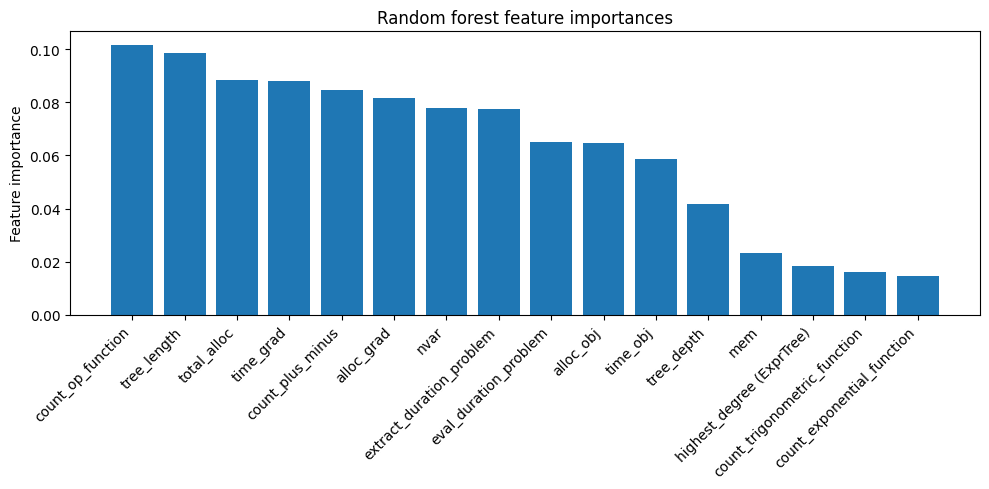

['./model_weights/best_rf_model_reg.pkl']

In [9]:
import numpy as np
import matplotlib.pyplot as plt

best_model = joblib.load('./model_weights/best_rf_model_reg.pkl')
# best_model = random_search.best_estimator_
rf_importances = best_model.feature_importances_
indices_rf = np.argsort(rf_importances)[::-1]  

plt.figure(figsize=(10, 5))
plt.bar(range(len(feature_cols_reg)), rf_importances[indices_rf])
plt.xticks(range(len(feature_cols_reg)), [feature_cols_reg[i] for i in indices_rf], rotation=45, ha="right")
plt.ylabel("Feature importance")
plt.title("Random forest feature importances")
plt.tight_layout()
plt.show()

joblib.dump(best_model, './model_weights/best_rf_model_reg.pkl')

In [10]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
pred = best_model.predict(X_test)
test_mse = mean_squared_error(y_test, pred)
test_r2  = r2_score(y_test, pred)
print(f"MSE={test_mse:.4f}  R²={test_r2:.4f}")

relative_error = np.abs(pred - y_test) / np.abs(y_test + 1e-8)

#exp((E[Y|xi])

thresholds = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
for i, col in enumerate(target_cols_reg):
    print(f"\n{col}:")
    print(f"Relative Error | Under Threshold | Percentage")
    for t in thresholds:
        rate = np.mean(relative_error[:, i] < t)
        print(f"  <{t:5.0%}:  {rate:.2%}")

MSE=1.4678  R²=0.5443

neval_obj:
Relative Error | Under Threshold | Percentage
  <   5%:  25.33%
  <  10%:  35.14%
  <  15%:  47.58%
  <  20%:  57.19%
  <  30%:  69.33%
  <  50%:  92.19%

neval_grad:
Relative Error | Under Threshold | Percentage
  <   5%:  24.21%
  <  10%:  33.35%
  <  15%:  43.98%
  <  20%:  53.70%
  <  30%:  66.51%
  <  50%:  85.67%

timed_bytes:
Relative Error | Under Threshold | Percentage
  <   5%:  73.37%
  <  10%:  91.88%
  <  15%:  97.67%
  <  20%:  99.21%
  <  30%:  99.93%
  <  50%:  99.98%


In [11]:
# import seaborn as sns
# x = df["timed_bytes"]
# sns.histplot(x=x)
# plt.ylim(0, 2000)
# plt.title("Distribution for timed_bytes")
# plt.plot()

### Using the predicted value of ["neval_obj", "neval_grad", "timed_bytes"] to predict time

In [12]:
X_train_time = best_model.predict(X_train)
X_test_time = best_model.predict(X_test)
y_train_time = np.log1p(train_df[target_col_model].to_numpy(dtype=float)).ravel()
y_test_time = np.log1p(test_df[target_col_model].to_numpy(dtype=float)).ravel()

In [13]:
time_predictor = RandomForestRegressor()
time_predictor.fit(X_train_time, y_train_time)
time_predictor.score(X_test_time, y_test_time)

-0.11947918265779234

In [14]:
# param_distributions = {
#     'n_estimators': randint(50, 500),
#     'max_depth': [None, 5, 10, 20, 30, 50],
#     'min_samples_split': randint(5, 50),
#     'min_samples_leaf': randint(2, 20),
#     'max_features': ['sqrt', 'log2', 0.5, 0.7],
#     'bootstrap': [True],
#     'min_impurity_decrease': uniform(0, 0.05),
#     'ccp_alpha': uniform(0, 0.05),
#     'criterion': ['squared_error', 'friedman_mse', 'poisson']
# }

# rf = RandomForestRegressor(random_state=42, n_jobs=1)

# time_random_search = RandomizedSearchCV(
#     rf,
#     param_distributions=param_distributions,
#     n_iter=200,
#     cv=5,
#     scoring='neg_mean_squared_error',
#     n_jobs=4,
#     random_state=42,
#     verbose=3,
#     return_train_score=True,
#     error_score='raise'
# )

# time_random_search.fit(X_train_time, y_train_time)

# print("\n" + "="*80)
# print("BEST RESULTS")
# print("="*80)
# print("Best parameters:", time_random_search.best_params_)
# print("Best CV score (neg MSE):", time_random_search.best_score_)
# print("Actual MSE:", -time_random_search.best_score_)

# results_df = pd.DataFrame(time_random_search.cv_results_)
# results_df['actual_mse'] = -results_df['mean_test_score']
# results_df = results_df.sort_values('actual_mse')

# print("\n" + "="*80)
# print("TOP 20 CONFIGURATIONS")
# print("="*80)
# top_cols = ['mean_test_score', 'std_test_score', 'mean_fit_time', 
#             'param_n_estimators', 'param_max_depth', 'param_max_features',
#             'param_min_samples_split', 'param_min_samples_leaf']
# print(results_df[top_cols].head(20).to_string())

# results_df.to_csv('rf_randomsearch_comprehensive_results.csv', index=False)


In [15]:
time_best_model = joblib.load('./model_weights/best_rf_model_time.pkl')
accuracy = time_best_model.score(X_test_time, y_test_time)
print(f"Time prediction accuracy based on predicted values={accuracy}")

joblib.dump(time_best_model, './model_weights/best_rf_model_time.pkl')

Time prediction accuracy based on predicted values=0.549759171601071


['./model_weights/best_rf_model_time.pkl']

In [16]:
pred = time_best_model.predict(X_test_time)
test_mse = mean_squared_error(y_test_time, pred)
test_r2  = r2_score(y_test_time, pred)
print(f"MSE={test_mse:.4f}  R²={test_r2:.4f}")

relative_error = np.abs(pred - y_test_time) / np.abs(y_test_time + 1e-8)

#exp((E[Y|xi])

thresholds = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
for i, col in enumerate(target_col_model):
    print(f"\n{col}:")
    print(f"Relative Error | Under Threshold | Percentage")
    for t in thresholds:
        rate = np.mean(relative_error < t)
        print(f"  <{t:5.0%}:  {rate:.2%}")

MSE=2.0334  R²=0.5498

stats_elapsed_time:
Relative Error | Under Threshold | Percentage
  <   5%:  6.49%
  <  10%:  8.21%
  <  15%:  10.44%
  <  20%:  11.86%
  <  30%:  15.56%
  <  50%:  33.42%


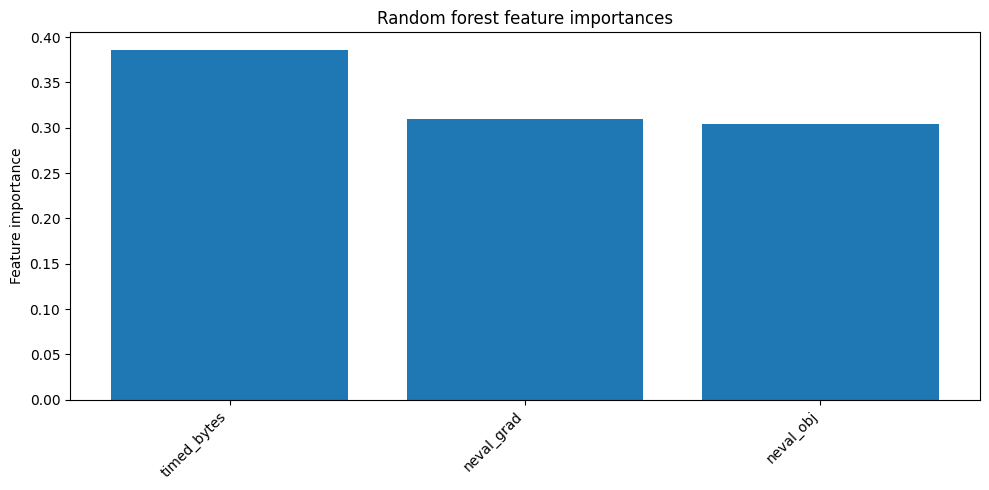

In [17]:
best_model_time = time_best_model
rf_importances = best_model_time.feature_importances_
indices_rf = np.argsort(rf_importances)[::-1]  

plt.figure(figsize=(10, 5))
plt.bar(range(len(target_cols_reg)), rf_importances[indices_rf])
plt.xticks(range(len(target_cols_reg)), [target_cols_reg[i] for i in indices_rf], rotation=45, ha="right")
plt.ylabel("Feature importance")
plt.title("Random forest feature importances")
plt.tight_layout()
plt.show()

### Using the actual value of ["neval_obj", "neval_grad", "timed_bytes"] to predict time

In [18]:
X_train_time = train_df[target_cols_reg]
X_test_time = test_df[target_cols_reg]
y_train_time = np.log1p(train_df[target_col_model].to_numpy(dtype=float)).ravel()
y_test_time = np.log1p(test_df[target_col_model].to_numpy(dtype=float)).ravel()

In [19]:
time_predictor = RandomForestRegressor()
time_predictor.fit(X_train_time, y_train_time)
time_predictor.score(X_test_time, y_test_time)

0.48745203536084325

In [20]:
# param_distributions = {
#     'n_estimators': randint(50, 500),
#     'max_depth': [5, 10, 15, 20, 30, None],
#     'min_samples_split': randint(2, 20),
#     'min_samples_leaf': randint(1, 10),
#     'max_features': ['sqrt', 'log2', 0.5],
#     'bootstrap': [True],
#     'min_impurity_decrease': uniform(0, 0.01),
#     'criterion': ['squared_error']
# }

# rf = RandomForestRegressor(random_state=42, n_jobs=1)

# time_random_search_raw = RandomizedSearchCV(
#     rf,
#     param_distributions=param_distributions,
#     n_iter=200,
#     cv=5,
#     scoring='neg_mean_squared_error',
#     n_jobs=6,
#     random_state=42,
#     verbose=2,
#     return_train_score=True,
#     error_score='raise'
# )

# time_random_search_raw.fit(X_train_time, y_train_time)

# print("\n" + "="*80)
# print("BEST RESULTS (1000 ITERATIONS)")
# print("="*80)
# print("Best parameters:", time_random_search_raw.best_params_)
# print("Best CV score (neg MSE):", time_random_search_raw.best_score_)
# print("Actual MSE:", -time_random_search_raw.best_score_)

# results_df = pd.DataFrame(time_random_search_raw.cv_results_)
# results_df['actual_mse'] = -results_df['mean_test_score']
# results_df = results_df.sort_values('actual_mse')

# print("\n" + "="*80)
# print("TOP 20 CONFIGURATIONS")
# print("="*80)
# top_cols = ['mean_test_score', 'std_test_score', 'mean_fit_time', 
#             'param_n_estimators', 'param_max_depth', 'param_max_features',
#             'param_min_samples_split', 'param_min_samples_leaf']
# print(results_df[top_cols].head(20).to_string())

# results_df.to_csv('rf_1000_iter_results.csv', index=False)

In [21]:
time_best_model_raw = joblib.load('./model_weights/best_rf_model_time_raw.pkl')
# time_best_model_raw = time_random_search_raw.best_estimator_
accuracy = time_best_model_raw.score(X_test_time, y_test_time)
print(f"Time prediction accuracy based on predicted values={accuracy}")

joblib.dump(time_best_model_raw, './model_weights/best_rf_model_time_raw.pkl')

Time prediction accuracy based on predicted values=0.747420843621583


['./model_weights/best_rf_model_time_raw.pkl']

In [22]:
pred = time_best_model_raw.predict(X_test_time)
test_mse = mean_squared_error(y_test_time, pred)
test_r2  = r2_score(y_test_time, pred)
print(f"MSE={test_mse:.4f}  R²={test_r2:.4f}")

relative_error = np.abs(pred - y_test_time) / np.abs(y_test_time + 1e-8)

#exp((E[Y|xi])

thresholds = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
for i, col in enumerate(target_col_model):
    print(f"\n{col}:")
    print(f"Relative Error | Under Threshold | Percentage")
    for t in thresholds:
        rate = np.mean(relative_error < t)
        print(f"  <{t:5.0%}:  {rate:.2%}")

MSE=1.1407  R²=0.7474

stats_elapsed_time:
Relative Error | Under Threshold | Percentage
  <   5%:  7.88%
  <  10%:  12.02%
  <  15%:  14.72%
  <  20%:  20.56%
  <  30%:  26.42%
  <  50%:  41.93%


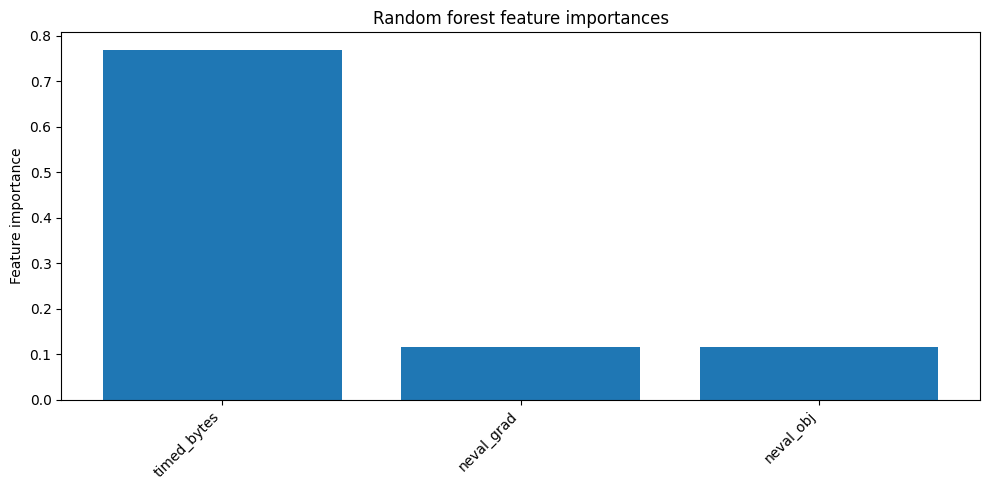

In [23]:
best_model_time_raw = time_best_model_raw
rf_importances = best_model_time_raw.feature_importances_
indices_rf = np.argsort(rf_importances)[::-1]  

plt.figure(figsize=(10, 5))
plt.bar(range(len(target_cols_reg)), rf_importances[indices_rf])
plt.xticks(range(len(target_cols_reg)), [target_cols_reg[i] for i in indices_rf], rotation=45, ha="right")
plt.ylabel("Feature importance")
plt.title("Random forest feature importances")
plt.tight_layout()
plt.show()

### Using linear regression model to predict time based on the ["timed_bytes", "neval_grad", "neval_obj"]

In [24]:
lr = LinearRegression()
lr_model = lr.fit(X_train_time, y_train_time)
accuracy = lr.score(X_test_time, y_test_time)
print(f"Default Linear Regression Model Test Accuracy={accuracy}")

Default Linear Regression Model Test Accuracy=-0.0068707623852164446


In [25]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_dist = {
    'alpha': np.logspace(-3, 3, 100),
    'positive': [True, False],
    'fit_intercept': [True, False]
}

ridge_search = RandomizedSearchCV(
    Ridge(),
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

ridge_search.fit(X_train_time, y_train_time)
print(f"Best params: {ridge_search.best_params_}")
print(f"Best CV R²: {ridge_search.best_score_}")
print(f"Test R²: {ridge_search.score(X_test_time, y_test_time)}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=6.1525e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=6.15045e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=6.15045e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=6.1525e-17): result may not be accur

Best params: {'positive': False, 'fit_intercept': True, 'alpha': 657.9332246575682}
Best CV R²: -8541.820120658334
Test R²: -0.006870756343572371


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=6.16174e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=6.17352e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=3.75e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=6.10837e-17): result may not be accura

### Now let's use stats_ellapsed_time to predict the corresponding best mem value

In [26]:
test_df["predicted_time"] = best_model_time_raw.predict(X_test_time)
test_df["predicted_time"]

0       0.356688
1       0.052422
2       0.052422
3       0.052422
4       0.052422
          ...   
4295    5.091488
4296    5.091488
4297    5.091488
4298    5.091488
4299    5.154975
Name: predicted_time, Length: 4300, dtype: float64

In [27]:
group_cols = ["name", "nvar"]
best_idx = df.groupby(group_cols)["stats_elapsed_time"].idxmin()
best_mem_map = df.loc[best_idx].set_index(group_cols)["mem"]
df["best_observed_mem"] = df.set_index(group_cols).index.map(best_mem_map)

In [28]:
group_cols = ["name", "nvar"]
best_idx = test_df.groupby(group_cols)["stats_elapsed_time"].idxmin()
best_mem_map = test_df.loc[best_idx].set_index(group_cols)["mem"]
test_df["best_observed_mem"] = test_df.set_index(group_cols).index.map(best_mem_map)
test_df["best_observed_time"] = test_df.groupby(group_cols)["stats_elapsed_time"].transform("min")

In [29]:
group_cols = ["name", "nvar"]
best_idx = test_df.groupby(group_cols)["predicted_time"].idxmin()
model_time_map = test_df.loc[best_idx].set_index(group_cols)["stats_elapsed_time"]
best_mem_map = test_df.loc[best_idx].set_index(group_cols)["mem"]
test_df["best_predicted_time"] = test_df.set_index(group_cols).index.map(model_time_map)
test_df["best_predicted_mem"] = test_df.set_index(group_cols).index.map(best_mem_map)

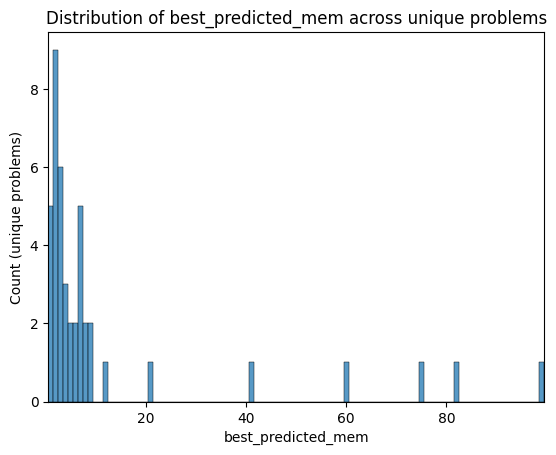

In [30]:
# %pip install seaborn
import seaborn as sns
x = test_df.groupby(['name', 'nvar'])['best_predicted_mem'].first()
sns.histplot(x=x, discrete=True)
plt.xlim(0.5, x.max() + 0.5)
plt.xlabel("best_predicted_mem")
plt.ylabel("Count (unique problems)")
plt.title("Distribution of best_predicted_mem across unique problems")
plt.show()

In [31]:
test_df.groupby(['name', 'nvar'])[['best_predicted_mem', 'best_observed_mem', 'predicted_time', 'stats_elapsed_time', 'best_observed_time', 'best_predicted_time']].first()

,,best_predicted_mem,best_observed_mem,predicted_time,stats_elapsed_time,best_observed_time,best_predicted_time
name,nvar,,,,,,
arglinb,100,2,1,0.356688,0.000229,0.000229,0.000294
argtrig,100,9,61,0.890241,0.013453,0.008126,0.010001
arwhead,1000,7,3,0.272655,0.058931,0.040062,0.048455
brownal,100,1,1,0.133161,0.000280,0.000280,0.000280
brybnd,10000,2,1,1.923238,23.019709,23.019709,25.739328
clplatea,961,2,97,2.028146,16.738348,1.057629,4.578721
clplatec,100,75,87,5.013591,0.999100,0.012869,0.013983
cosine,100,1,1,0.153475,0.000634,0.000634,0.000634
cragglvy,1000,4,12,0.176461,0.415430,0.247496,0.297504


Proportions of best_predicted_mem:
best_predicted_mem
1     0.116279
2     0.209302
3     0.139535
4     0.069767
5     0.046512
6     0.046512
7     0.116279
8     0.046512
9     0.046512
12    0.023256
21    0.023256
41    0.023256
60    0.023256
75    0.023256
82    0.023256
99    0.023256
Name: proportion, dtype: float64


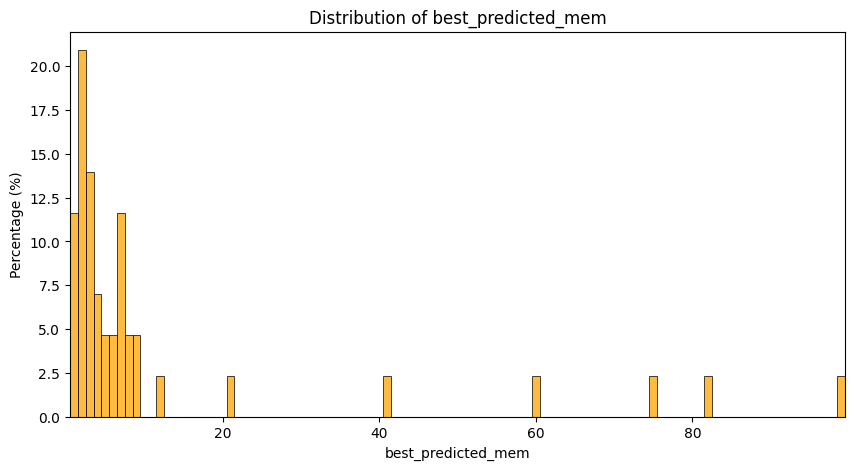

In [32]:
x = test_df["best_predicted_mem"]
proportions = x.value_counts(normalize=True).sort_index()

print("Proportions of best_predicted_mem:")
print(proportions)

plt.figure(figsize=(10, 5))
sns.histplot(x=x, stat='percent', discrete=True, color='orange')
plt.xlabel("best_predicted_mem")
plt.ylabel("Percentage (%)")
plt.title("Distribution of best_predicted_mem")
plt.xlim(0.5, x.max() + 0.5)
plt.show()

### Mem evaluation metrics

In [33]:
# How far off is the predicted mem from actual (in mem units)
mem_absolute_error = abs(test_df['best_predicted_mem'] - test_df['best_observed_mem'])
mame = np.mean(mem_absolute_error)
print(f"Mean Absolute Mem Error: {mame:.2f}")
print(f"Median Absolute Mem Error: {np.median(mem_absolute_error):.2f}")

Mean Absolute Mem Error: 29.77
Median Absolute Mem Error: 12.00


In [34]:
# How close are the predictions? 1.0 = perfect, 0.0 = very far
mem_match_ratio = np.minimum(test_df['best_predicted_mem'], 
                              test_df['best_observed_mem']) / \
                  np.maximum(test_df['best_predicted_mem'], 
                              test_df['best_observed_mem'])

mean_match_ratio = np.mean(mem_match_ratio)
print(f"Mean Mem Match Ratio: {mean_match_ratio:.3f}")
# 1.0 = perfect match
# 0.5 = off by 2x (e.g., pred=50, actual=100)
# 0.1 = off by 10x (e.g., pred=10, actual=100)

Mean Mem Match Ratio: 0.384


In [35]:
group_cols = ['name', 'nvar']
unique_problems = test_df.groupby(group_cols).first().reset_index()

print(f"Total unique test problems: {len(unique_problems)}\n")

Total unique test problems: 43



In [36]:
print("="*60)
print("MEM PREDICTION ACCURACY")
print("="*60)

exact_match = (unique_problems['best_predicted_mem'] == unique_problems['best_observed_mem']).mean()
print(f"Exact match rate: {exact_match:.1%}")

within_5 = (abs(unique_problems['best_predicted_mem'] - unique_problems['best_observed_mem']) <= 5).mean()
within_10 = (abs(unique_problems['best_predicted_mem'] - unique_problems['best_observed_mem']) <= 10).mean()
within_20 = (abs(unique_problems['best_predicted_mem'] - unique_problems['best_observed_mem']) <= 20).mean()

print(f"\nWithin tolerance:")
print(f"  ± 5 mem units:  {within_5:.1%}")
print(f"  ± 10 mem units: {within_10:.1%}")
print(f"  ± 20 mem units: {within_20:.1%}")

MEM PREDICTION ACCURACY
Exact match rate: 14.0%

Within tolerance:
  ± 5 mem units:  37.2%
  ± 10 mem units: 48.8%
  ± 20 mem units: 60.5%


In [37]:
print("="*60)
print("RANKING QUALITY")
print("="*60)

from scipy.stats import spearmanr

rank_corrs = []
for _, group_data in test_df.groupby(group_cols):
    true_order = group_data.sort_values('mem')['stats_elapsed_time'].values
    pred_order = group_data.sort_values('mem')['predicted_time'].values
    corr, _ = spearmanr(true_order, pred_order)
    rank_corrs.append(corr)

print(f"Mean Spearman correlation: {np.mean(rank_corrs):.3f}")
print(f"Median Spearman correlation: {np.median(rank_corrs):.3f}")

RANKING QUALITY
Mean Spearman correlation: 0.157
Median Spearman correlation: 0.138


### Baselines Comparisons

In [38]:
df.columns

Index(['extract_duration_problem', 'highest_degree (ExprTree)', 'time_grad',
       'neval_grad', 'neval_obj', 'nvar', 'count_exponential_function',
       'time_obj', 'timed_bytes', 'mem', 'alloc_obj', 'count_op_function',
       'eval_duration_problem', 'alloc_grad', 'name',
       'count_trigonometric_function', 'tree_depth', 'count_plus_minus',
       'tree_length', 'total_alloc', 'stats_elapsed_time', 'mem_count',
       'best_observed_mem'],
      dtype='object')

In [39]:
if 'baseline1_time' in test_df.columns:
    test_df = test_df.drop(columns='baseline1_time')
baseline1_values = df[df['mem'] == 5][['name', 'nvar', 'stats_elapsed_time']].drop_duplicates(['name', 'nvar'])
test_df = test_df.merge(
    baseline1_values.rename(columns={'stats_elapsed_time': 'baseline1_time'}), 
    on=['name', 'nvar'], 
    how='left'
)
test_df

,extract_duration_problem,highest_degree (ExprTree),time_grad,neval_grad,neval_obj,nvar,count_exponential_function,time_obj,timed_bytes,mem,alloc_obj,count_op_function,eval_duration_problem,alloc_grad,name,count_trigonometric_function,tree_depth,count_plus_minus,tree_length,total_alloc,stats_elapsed_time,mem_count,predicted_time,best_observed_mem,best_observed_time,best_predicted_time,best_predicted_mem,baseline1_time
0,6.859471,2.0,1.029701,8.0,56.0,100,0.0,0.288629,20176.0,1,45676488.0,20600.0,3.275820,52547568.0,arglinb,0.0,8.0,400.0,40200.0,98224056.0,0.000229,100,0.356688,1,0.000229,0.000294,2,0.000234
1,6.859471,2.0,1.029701,4.0,28.0,100,0.0,0.288629,23720.0,2,45676488.0,20600.0,3.275820,52547568.0,arglinb,0.0,8.0,400.0,40200.0,98224056.0,0.000294,100,0.052422,1,0.000229,0.000294,2,0.000234
2,6.859471,2.0,1.029701,4.0,28.0,100,0.0,0.288629,27192.0,3,45676488.0,20600.0,3.275820,52547568.0,arglinb,0.0,8.0,400.0,40200.0,98224056.0,0.000294,100,0.052422,1,0.000229,0.000294,2,0.000234
3,6.859471,2.0,1.029701,4.0,28.0,100,0.0,0.288629,30728.0,4,45676488.0,20600.0,3.275820,52547568.0,arglinb,0.0,8.0,400.0,40200.0,98224056.0,0.000236,100,0.052422,1,0.000229,0.000294,2,0.000234
4,6.859471,2.0,1.029701,4.0,28.0,100,0.0,0.288629,34200.0,5,45676488.0,20600.0,3.275820,52547568.0,arglinb,0.0,8.0,400.0,40200.0,98224056.0,0.000234,100,0.052422,1,0.000229,0.000294,2,0.000234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4295,74.643566,2.0,1.054803,59.0,68.0,10000,0.0,0.113105,31484720.0,96,75185144.0,57501.0,1.302962,471227304.0,woods,0.0,7.0,27501.0,42500.0,546412448.0,7.757891,100,5.091488,12,7.359282,7.748290,7,9.446440
4296,74.643566,2.0,1.054803,59.0,68.0,10000,0.0,0.113105,31804864.0,97,75185144.0,57501.0,1.302962,471227304.0,woods,0.0,7.0,27501.0,42500.0,546412448.0,7.755893,100,5.091488,12,7.359282,7.748290,7,9.446440
4297,74.643566,2.0,1.054803,59.0,68.0,10000,0.0,0.113105,32125008.0,98,75185144.0,57501.0,1.302962,471227304.0,woods,0.0,7.0,27501.0,42500.0,546412448.0,7.753765,100,5.091488,12,7.359282,7.748290,7,9.446440
4298,74.643566,2.0,1.054803,59.0,68.0,10000,0.0,0.113105,32445152.0,99,75185144.0,57501.0,1.302962,471227304.0,woods,0.0,7.0,27501.0,42500.0,546412448.0,7.755922,100,5.091488,12,7.359282,7.748290,7,9.446440


In [40]:
GLOBAL_BEST_MEM = 87
if 'baseline2_time' in test_df.columns:
    test_df = test_df.drop(columns='baseline2_time')
baseline2_values = df[df['mem'] == GLOBAL_BEST_MEM][['name', 'nvar', 'stats_elapsed_time']].drop_duplicates(['name', 'nvar'])
test_df = test_df.merge(
    baseline2_values.rename(columns={'stats_elapsed_time': 'baseline2_time'}), 
    on=['name', 'nvar'], 
    how='left'
)
test_df

,extract_duration_problem,highest_degree (ExprTree),time_grad,neval_grad,neval_obj,nvar,count_exponential_function,time_obj,timed_bytes,mem,alloc_obj,count_op_function,eval_duration_problem,alloc_grad,name,count_trigonometric_function,tree_depth,count_plus_minus,tree_length,total_alloc,stats_elapsed_time,mem_count,predicted_time,best_observed_mem,best_observed_time,best_predicted_time,best_predicted_mem,baseline1_time,baseline2_time
0,6.859471,2.0,1.029701,8.0,56.0,100,0.0,0.288629,20176.0,1,45676488.0,20600.0,3.275820,52547568.0,arglinb,0.0,8.0,400.0,40200.0,98224056.0,0.000229,100,0.356688,1,0.000229,0.000294,2,0.000234,0.000289
1,6.859471,2.0,1.029701,4.0,28.0,100,0.0,0.288629,23720.0,2,45676488.0,20600.0,3.275820,52547568.0,arglinb,0.0,8.0,400.0,40200.0,98224056.0,0.000294,100,0.052422,1,0.000229,0.000294,2,0.000234,0.000289
2,6.859471,2.0,1.029701,4.0,28.0,100,0.0,0.288629,27192.0,3,45676488.0,20600.0,3.275820,52547568.0,arglinb,0.0,8.0,400.0,40200.0,98224056.0,0.000294,100,0.052422,1,0.000229,0.000294,2,0.000234,0.000289
3,6.859471,2.0,1.029701,4.0,28.0,100,0.0,0.288629,30728.0,4,45676488.0,20600.0,3.275820,52547568.0,arglinb,0.0,8.0,400.0,40200.0,98224056.0,0.000236,100,0.052422,1,0.000229,0.000294,2,0.000234,0.000289
4,6.859471,2.0,1.029701,4.0,28.0,100,0.0,0.288629,34200.0,5,45676488.0,20600.0,3.275820,52547568.0,arglinb,0.0,8.0,400.0,40200.0,98224056.0,0.000234,100,0.052422,1,0.000229,0.000294,2,0.000234,0.000289
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4295,74.643566,2.0,1.054803,59.0,68.0,10000,0.0,0.113105,31484720.0,96,75185144.0,57501.0,1.302962,471227304.0,woods,0.0,7.0,27501.0,42500.0,546412448.0,7.757891,100,5.091488,12,7.359282,7.748290,7,9.446440,7.757396
4296,74.643566,2.0,1.054803,59.0,68.0,10000,0.0,0.113105,31804864.0,97,75185144.0,57501.0,1.302962,471227304.0,woods,0.0,7.0,27501.0,42500.0,546412448.0,7.755893,100,5.091488,12,7.359282,7.748290,7,9.446440,7.757396
4297,74.643566,2.0,1.054803,59.0,68.0,10000,0.0,0.113105,32125008.0,98,75185144.0,57501.0,1.302962,471227304.0,woods,0.0,7.0,27501.0,42500.0,546412448.0,7.753765,100,5.091488,12,7.359282,7.748290,7,9.446440,7.757396
4298,74.643566,2.0,1.054803,59.0,68.0,10000,0.0,0.113105,32445152.0,99,75185144.0,57501.0,1.302962,471227304.0,woods,0.0,7.0,27501.0,42500.0,546412448.0,7.755922,100,5.091488,12,7.359282,7.748290,7,9.446440,7.757396


In [41]:
test_df = test_df.rename(columns={'best_observed_time' : 'oracle_time'})
test_df

,extract_duration_problem,highest_degree (ExprTree),time_grad,neval_grad,neval_obj,nvar,count_exponential_function,time_obj,timed_bytes,mem,alloc_obj,count_op_function,eval_duration_problem,alloc_grad,name,count_trigonometric_function,tree_depth,count_plus_minus,tree_length,total_alloc,stats_elapsed_time,mem_count,predicted_time,best_observed_mem,oracle_time,best_predicted_time,best_predicted_mem,baseline1_time,baseline2_time
0,6.859471,2.0,1.029701,8.0,56.0,100,0.0,0.288629,20176.0,1,45676488.0,20600.0,3.275820,52547568.0,arglinb,0.0,8.0,400.0,40200.0,98224056.0,0.000229,100,0.356688,1,0.000229,0.000294,2,0.000234,0.000289
1,6.859471,2.0,1.029701,4.0,28.0,100,0.0,0.288629,23720.0,2,45676488.0,20600.0,3.275820,52547568.0,arglinb,0.0,8.0,400.0,40200.0,98224056.0,0.000294,100,0.052422,1,0.000229,0.000294,2,0.000234,0.000289
2,6.859471,2.0,1.029701,4.0,28.0,100,0.0,0.288629,27192.0,3,45676488.0,20600.0,3.275820,52547568.0,arglinb,0.0,8.0,400.0,40200.0,98224056.0,0.000294,100,0.052422,1,0.000229,0.000294,2,0.000234,0.000289
3,6.859471,2.0,1.029701,4.0,28.0,100,0.0,0.288629,30728.0,4,45676488.0,20600.0,3.275820,52547568.0,arglinb,0.0,8.0,400.0,40200.0,98224056.0,0.000236,100,0.052422,1,0.000229,0.000294,2,0.000234,0.000289
4,6.859471,2.0,1.029701,4.0,28.0,100,0.0,0.288629,34200.0,5,45676488.0,20600.0,3.275820,52547568.0,arglinb,0.0,8.0,400.0,40200.0,98224056.0,0.000234,100,0.052422,1,0.000229,0.000294,2,0.000234,0.000289
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4295,74.643566,2.0,1.054803,59.0,68.0,10000,0.0,0.113105,31484720.0,96,75185144.0,57501.0,1.302962,471227304.0,woods,0.0,7.0,27501.0,42500.0,546412448.0,7.757891,100,5.091488,12,7.359282,7.748290,7,9.446440,7.757396
4296,74.643566,2.0,1.054803,59.0,68.0,10000,0.0,0.113105,31804864.0,97,75185144.0,57501.0,1.302962,471227304.0,woods,0.0,7.0,27501.0,42500.0,546412448.0,7.755893,100,5.091488,12,7.359282,7.748290,7,9.446440,7.757396
4297,74.643566,2.0,1.054803,59.0,68.0,10000,0.0,0.113105,32125008.0,98,75185144.0,57501.0,1.302962,471227304.0,woods,0.0,7.0,27501.0,42500.0,546412448.0,7.753765,100,5.091488,12,7.359282,7.748290,7,9.446440,7.757396
4298,74.643566,2.0,1.054803,59.0,68.0,10000,0.0,0.113105,32445152.0,99,75185144.0,57501.0,1.302962,471227304.0,woods,0.0,7.0,27501.0,42500.0,546412448.0,7.755922,100,5.091488,12,7.359282,7.748290,7,9.446440,7.757396


In [42]:
# Model Regret (The memory value predicted by your RF)
test_df['model_regret'] = test_df['best_predicted_time'] - test_df['oracle_time']

# Baseline 1 Regret (Always using mem=5)
test_df['baseline1_regret'] = test_df['baseline1_time'] - test_df['oracle_time']

# Baseline 2 Regret (Always using the best fixed memory found in training)
test_df['baseline2_regret'] = test_df['baseline2_time'] - test_df['oracle_time']
test_df_unique = test_df.groupby(["name", "nvar"]).first()

In [43]:
print("\n" + "="*40)
print("AVERAGE REGRET (SECONDS ABOVE ORACLE)")
print("="*40)
print(test_df_unique[['model_regret', 'baseline1_regret', 'baseline2_regret']].mean().to_string())

print("\n" + "="*40)
print("REGRET QUANTILES (50% / 75% / 95%)")
print("="*40)
print(test_df_unique[['model_regret', 'baseline1_regret', 'baseline2_regret']].quantile([0.5, 0.75, 0.95]))


AVERAGE REGRET (SECONDS ABOVE ORACLE)
model_regret        24.957503
baseline1_regret    25.146670
baseline2_regret     5.722437

REGRET QUANTILES (50% / 75% / 95%)
      model_regret  baseline1_regret  baseline2_regret
0.50      0.035661          0.267955          0.095412
0.75      4.466762          5.712914          0.670555
0.95     84.461522         67.109141         17.816225


In [44]:
# Calculate ratios per problem (Relative Slowdown)
test_df_unique['model_ratio'] = test_df_unique['best_predicted_time'] / test_df_unique['oracle_time']
test_df_unique['baseline1_ratio'] = test_df_unique['baseline1_time'] / test_df_unique['oracle_time']
test_df_unique['baseline2_ratio'] = test_df_unique['baseline2_time'] / test_df_unique['oracle_time']

# Print the comparison
print("\n" + "="*40)
print("PERFORMANCE RATIO (1.0 = PERFECTION)")
print("="*40)
cols = ['model_ratio', 'baseline1_ratio', 'baseline2_ratio']
print(test_df_unique[cols].quantile([0.5, 0.75, 0.95]))


PERFORMANCE RATIO (1.0 = PERFECTION)
      model_ratio  baseline1_ratio  baseline2_ratio
0.50     1.202056         1.233671         1.111844
0.75     1.585533         1.782548         1.476112
0.95     2.279532         5.278511         2.266124
